In [1]:
from typing import TypedDict, List

class QuizState(TypedDict):
    topic: str
    notes: str
    question: str
    attempts: int

class TutorState(TypedDict):
    topics: List[dict]
    topic_index: int
    quiz: QuizState
    messages: List
    step: str   # 🔥 IMPORTANT

In [2]:
def setup_topic(state: TutorState):
    topic = state["topics"][state["topic_index"]]

    return {
        "quiz": {
            "topic": topic["name"],
            "notes": topic["notes"],
            "question": "",
            "attempts": 0
        },
        "step": "ask_question"
    }

In [3]:
def ask_question(state: TutorState):

    prompt = f"""
    Create a simple conceptual question.

    Topic: {state["quiz"]["topic"]}
    Notes: {state["quiz"]["notes"]}
    """

    question = llm.invoke(prompt).content

    return {
        "quiz": {
            **state["quiz"],
            "question": question
        },
        "messages": state["messages"] + [
            {"role": "assistant", "text": question}
        ],
        "step": "await_answer"   # 🔥 STOP HERE
    }

In [4]:
def evaluate_answer(state: TutorState):

    user_msg = state["messages"][-1]["text"]

    prompt = f"""
    Evaluate the student's answer.

    Topic: {state["quiz"]["topic"]}
    Notes: {state["quiz"]["notes"]}

    Answer: {user_msg}

    Return:
    correct: true/false
    feedback: short explanation
    """

    result = llm.invoke(prompt).content.lower()

    correct = "true" in result

    if correct:
        return {
            "messages": state["messages"] + [
                {"role": "assistant", "text": "Correct! Moving ahead."}
            ],
            "step": "next_topic"
        }

    return {
        "messages": state["messages"] + [
            {"role": "assistant", "text": "Not quite. Try again."}
        ],
        "quiz": {
            **state["quiz"],
            "attempts": state["quiz"]["attempts"] + 1
        },
        "step": "hint"
    }

In [5]:
def give_hint(state: TutorState):

    prompt = f"""
    Give a hint for this concept.

    Topic: {state["quiz"]["topic"]}
    Notes: {state["quiz"]["notes"]}
    """

    hint = llm.invoke(prompt).content

    return {
        "messages": state["messages"] + [
            {"role": "assistant", "text": hint}
        ],
        "step": "ask_question"
    }

In [6]:
def next_topic(state: TutorState):

    next_index = state["topic_index"] + 1

    if next_index >= len(state["topics"]):
        return {
            "messages": state["messages"] + [
                {"role": "assistant", "text": "You completed all topics!"}
            ],
            "step": "end"
        }

    return {
        "topic_index": next_index,
        "step": "setup_topic"
    }

In [7]:
from langgraph.graph import END

def router(state: TutorState):

    if state["step"] == "setup_topic":
        return "setup_topic"

    if state["step"] == "ask_question":
        return "ask_question"

    if state["step"] == "await_answer":
        return END   # 🔥 STOP for frontend

    if state["step"] == "evaluate":
        return "evaluate"

    if state["step"] == "hint":
        return "hint"

    if state["step"] == "next_topic":
        return "next_topic"

    if state["step"] == "end":
        return END

In [8]:
from langgraph.graph import StateGraph

builder = StateGraph(TutorState)

builder.add_node("setup_topic", setup_topic)
builder.add_node("ask_question", ask_question)
builder.add_node("evaluate", evaluate_answer)
builder.add_node("hint", give_hint)
builder.add_node("next_topic", next_topic)

builder.set_entry_point("setup_topic")

builder.add_conditional_edges(
    "setup_topic", router,
    {
        "ask_question": "ask_question"
    }
)

builder.add_conditional_edges(
    "ask_question", router,
    {
        END: END
    }
)

builder.add_conditional_edges(
    "evaluate", router,
    {
        "hint": "hint",
        "next_topic": "next_topic"
    }
)

builder.add_conditional_edges(
    "hint", router,
    {
        "ask_question": "ask_question"
    }
)

builder.add_conditional_edges(
    "next_topic", router,
    {
        "setup_topic": "setup_topic",
        END: END
    }
)

graph = builder.compile()

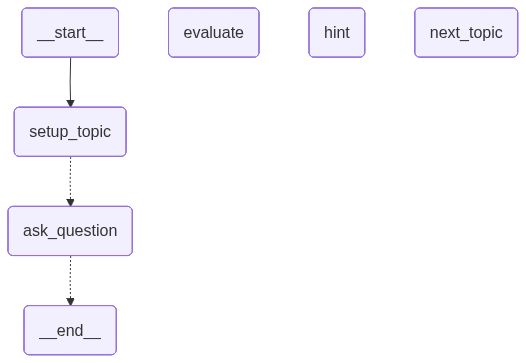

In [9]:
graph